<a href="https://colab.research.google.com/github/Ahmedgamale/Industrial-Inspection-Robot/blob/main/notebooks/spectral_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_excel(
    "Merged_Sensor_Dataset.xlsx",
    sheet_name="AS7265x_Spectral_Data"
)

df.head()


,410,435,460,485,510,535,560,585,610,645,680,705,730,760,810,860,900,940,class_label,dataset_type
0,30.033,31.501,33.805,35.177,36.829,38.535,42.242,53.689,87.268,182.515,239.984,198.733,117.528,55.884,29.254,22.940,19.031,15.557,red,color_classification
1,24.776,27.216,29.056,30.671,31.886,33.433,35.409,43.488,69.443,119.066,148.074,127.410,86.555,44.648,24.152,19.215,16.987,13.136,red,color_classification
2,15.945,17.204,19.287,19.679,20.711,21.371,22.009,26.095,43.258,103.112,142.401,114.654,63.248,27.610,15.320,12.310,10.061,8.441,red,color_classification
3,20.170,21.501,23.395,25.917,26.009,27.704,28.910,39.202,69.986,152.226,202.644,162.055,97.772,42.600,20.740,15.589,13.391,10.502,red,color_classification
4,19.206,20.650,21.866,23.094,23.808,24.056,24.582,28.633,42.350,94.439,126.683,101.160,59.526,28.456,18.255,15.361,12.893,10.084,red,color_classification


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# X = spectral features (410 → 940)
X = df.drop(columns=['class_label', 'dataset_type'], errors='ignore')

# y = labels (color or material)
y = df['class_label']

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)



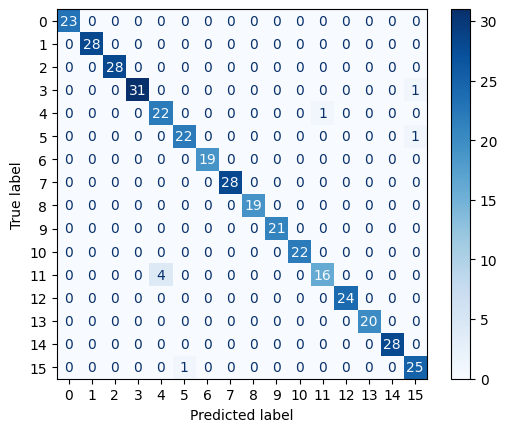

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.9791666666666666

Classification Report:

              precision    recall  f1-score   support

       black       1.00      1.00      1.00        23
        blue       1.00      1.00      1.00        28
      cotton       1.00      1.00      1.00        28
        cyan       1.00      0.97      0.98        32
       glass       0.85      0.96      0.90        23
       green       0.96      0.96      0.96        23
     magenta       1.00      1.00      1.00        19
       metal       1.00      1.00      1.00        28
       paper       1.00      1.00      1.00        19
     plastic       1.00      1.00      1.00        21
         red       1.00      1.00      1.00        22
      rubber       0.94      0.80      0.86        20
       water       1.00      1.00      1.00        24
       white       1.00      1.00      1.00        20
        wood       1.00      1.00      1.00        28
      yellow       0.93      0.96      0.94        26

    accuracy              